# Extração de bases usando HOG e LBP - Projeto 01

> **Autores:** Alexandre Maciel e Vinicius de Lima.

Esse notebook prepara as bases com as caractéristicas extraídas das raças de cachorro Samoieda e Pub e das raças de gato Russian Blue e Birman, usando os algoritmos _Local Binary Pattern_ (LBP), _Histogram of Oriented Gradients_ (HOG) e a redução de dimensionalidade (para extrações realizadas pelo HOG) usando _Principal Component Analysis_ (PCA). O objetivo é preparar o que é necessário para implementar um modelo de classificação em cima dessas características. 

Para referência, as imagens de cada uma das raças são as seguintes:

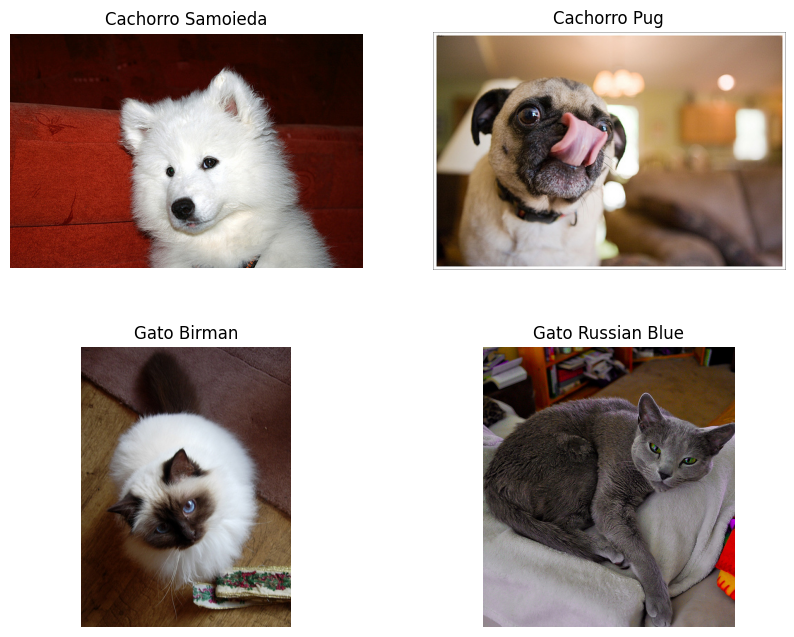

In [104]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

samples = [
    "assets/samoyed.jpg",
    "assets/pug.jpg",
    "assets/Birman.jpg",
    "assets/Russian_Blue.jpg",
]
captions = [
    "Cachorro Samoieda",
    "Cachorro Pug",
    "Gato Birman",
    "Gato Russian Blue",
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, sample, caption in zip(axes.ravel(), samples, captions):
    img = mpimg.imread(sample)
    ax.imshow(img)
    ax.set_title(caption, fontsize=12)
    ax.axis("off")

## Algoritmos

Agora vamos definir os algoritmos para extrair as características das imagens, vamos definir 3 funções que serão, uma para extrair as características usando o LBP, outra usando o HOG e a terceira para reduzir a dimensionalidade usando o PCA.

As 3 funções serão nomeadas como:

- `lbp_extract_ft`: Extração de características usando o LBP.
- `hog_extract_ft`: Extração de características usando o HOG.
- `pca_exec`: Diminuição da dimensionalidade usando o PCA.

Para definir se determinada é a imagem de um gato ou de um cachorro, vamos definir duas funções, `iscat` e `isdog`. Elas irão verificar se o nome de uma imagem possui a substring correspondente a raça. Além disso, já importaremos as dependências comuns para realizar a extração das características. Também, criaremos uma utilitaria para gerar um dataframe a partir de um dicionário de características que segue o formato:

```json
{
    "cat_feats": [...],
    "dog_feats": [...]
}
```

O data frame retornado terá o seguinte formato:

```csv
feat_0,feat_1,feat_2,...,feat_n, label
x_0,x_1,x_2,...,x_n,"cat"
x_0,x_1,x_2,...,x_n,"dog"
```

In [1]:
import numpy as np
import pandas as pd

from skimage.color import rgb2gray
from skimage.io import imread
from skimage.transform import resize

def iscat(name: str) -> bool:
    for s in ["Russian_Blue", "Birman"]:
        if s in name:
            return True
    return False


def isdog(name: str) -> bool:
    for s in ["samoyed", "pug"]:
        if s in name:
            return True
    return False

def mkdf(fts: dict[str, list[float]]) -> pd.DataFrame:
    cat = np.asarray(fts["cat_feats"])
    dog = np.asarray(fts["dog_feats"])

    xs = np.vstack([cat, dog])
    ys = np.array(["cat"] * len(cat) + ["dog"] * len(dog))

    df = pd.DataFrame(xs, columns=[f"feat_{i}" for i in range(xs.shape[1])])
    df["label"] = ys

    return df

### LBP (`lbp_extract_ft`)

A função irá receber 3 argumentos:

- `img_files`: A lista de caminhos para as imagens a serem extraídas as características.
- `res`: A resolução da imagem a ser extraída as características.
- `radius`: O raio da vizinhança do algoritmo.

In [ ]:
from skimage.feature import local_binary_pattern

def lbp_extract_ft(
    imgs_files: list[str],
    res: int,
    radius: int,
) -> dict[str, list[float]]:
    points = radius * 2
    cat_feats = []
    dog_feats = []

    for file in imgs_files:
        print(file)
        img = resize(imread(file), (res, res), anti_aliasing=True)
        grayed_img = (rgb2gray(img) * 255).astype(np.uint8)

        lbp = local_binary_pattern(
            image=grayed_img,
            P=points,
            R=radius,
            method="uniform",
        )
        hist, _ = np.histogram(
            lbp.ravel(),
            bins=points + 2,
            range=(0, points + 2),
        )
        hist = hist.astype(np.float64)
        hist /= hist.sum()

        if iscat(file):
            cat_feats.append(hist)
        elif isdog(file):
            dog_feats.append(hist)

    return {"cat_feats": cat_feats, "dog_feats": dog_feats}

**Exemplo de uso:**

In [ ]:
example_cat_img = "assets/Birman.jpg"
example_dog_img = "assets/pug.jpg"

lbp_extract_ft([example_cat_img, example_dog_img], 128, 3)

{'cat_feats': [array([0.06884766, 0.11505127, 0.14251709, 0.26776123, 0.1361084 ,
         0.09960938, 0.0680542 , 0.10205078])],
 'dog_feats': [array([0.06481934, 0.08978271, 0.14587402, 0.31170654, 0.13983154,
         0.09515381, 0.05377197, 0.09906006])]}

### HOG (`hog_extract_ft`)

Para o HOG a interface será a análoga, a função também irá receber 3 argumentos:
- `img_files`: A lista de caminhos para as imagens a serem extraídas as características.
- `res`: A resolução da imagem a ser extraída as características.
- `px`: A quantidade de pixels por célula.

In [ ]:
from skimage.feature import hog

def hog_extract_ft(
    img_files: list[str],
    res: int,
    px: int,
) -> dict[str, list[float]]:
    cat_feats = []
    dog_feats = []

    for file in img_files:
        img = resize(imread(file), (res, res), anti_aliasing=True)
        grayed_img = rgb2gray(img)

        ft = hog(grayed_img, pixels_per_cell=(px, px))

        if iscat(file):
            cat_feats.append(ft)
        elif isdog(file):
            dog_feats.append(ft)

    return {"cat_feats": cat_feats, "dog_feats": dog_feats}


**Exemplo de uso:**

In [ ]:
example_cat_img = "assets/Birman.jpg"
example_dog_img = "assets/pug.jpg"

hog_extract_ft([example_cat_img, example_dog_img], 128, 8)

{'cat_feats': [array([0.03642172, 0.02488911, 0.01879459, ..., 0.01731834, 0.03013673,
         0.01512851], shape=(15876,))],
 'dog_feats': [array([0.04463941, 0.09617635, 0.        , ..., 0.04502529, 0.03437213,
         0.00518781], shape=(15876,))]}

### PCA (`pca_exec`)

A função que encapsula o PCA, receberá o dataframe em que estão as características extraídas e o número de componentes:

- `xs`: Dataframe do pandas que representa os $x$'s do dataframe original.
- `n_components`: Porcentagem de componentes no PCA, um número em $[0, 1]$.

A função irá retornar um dataframe, com colunas na forma:

```csv
feat_0,feat_1,feat_2,...,feat_n
x_0,x_1,x_2,...,x_n
```

In [ ]:
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


def pca_exec(xs: pd.DataFrame, n_components: float) -> pd.DataFrame:
    std = StandardScaler().fit_transform(xs)
    pca = PCA(n_components=n_components).fit_transform(std)

    ret = pd.DataFrame(
        data=pca,
        columns=[f"feat_{i}" for i in range(pca.shape[1])],
    )

    return ret

**Exemplo de uso:**

In [ ]:
example_imgs = [
    "assets/pug.jpg",
    "assets/samoyed.jpg",
    "assets/Birman.jpg",
    "assets/Russian_Blue.jpg",
]


fts = hog_extract_ft(example_imgs, 256, 8)

cat = np.asarray(fts["cat_feats"])
dog = np.asarray(fts["dog_feats"])
xs = np.vstack([cat, dog])

df = pd.DataFrame(
    xs,
    columns=[f"feat_{i}" for i in range(xs.shape[1])],
)

new_df = pca_exec(df, 0.90)

print("Quantidade de atributos antes:", len(df.columns[:-1]))
print("Quantidade de atributos depois:", len(new_df.columns[:-1]))

Quantidade de atributos antes: 72899
Quantidade de atributos depois: 2


## Geração das bases

Por fim, vamos implementar o algoritmo que gera as bases que serão usadas posteriormente. 

Serão gerados 19 datasets, com diferentes características de extração entre si, isto é, resolução da imagem, quantidade de pixels por célula (no caso do HOG), raio (no caso do LBP), e número de componentes (no caso do PCA).

- **LBP:** A resolução se manterá fixa em `256x256` e o raio irá oscilar entre `3`, `6` e `12`.
- **HOG:** A resolução irá variar entre `128x128` e `256x256` e quantidade de píxels por célula irá variar entre `8x8`, `16x16` e `32x32`.
- **PCA:** O número de componentes irá oscilar entre `90%` e `75%` para todas as bases geradas do HOG.

Durante a execução garanta que o diretório `images` existe e que possuí imagens seguindo a nomeclatura:

```plain
Birman_1.jpg
Birman_2.jpg
...
Birman_n.jpg
Russian_Blue_1.jpg
Russian_Blue_2.jpg
...
Russian_Blue_n.jpg
pug_1.jpg
pug_2.jpg
...
pug_n.jpg
samoyed_1.jpg
samoyed_2.jpg
...
samoyed_n.jpg
```

As opções serão definidas a seguir:

In [105]:
import os

lbp_options = {"radius": [3, 6, 12], "resolution": [256]}
hog_options = {"pixels": [8, 16, 32], "resolution": [128, 256]}
pca_options = {"components": [0.75, 0.90]}

imgs_path = "./images"
imgs_files = [os.path.join(imgs_path, file) for file in os.listdir(imgs_path)]

print("lbp options:", lbp_options)
print("hog options:", hog_options)
print("pca opts:", pca_options)
print("img qtd:", len(imgs_files))

lbp options: {'radius': [3, 6, 12], 'resolution': [256]}
hog options: {'pixels': [8, 16, 32], 'resolution': [128, 256]}
pca opts: {'components': [0.75, 0.9]}
img qtd: 800


Além disso, vamos criar o diretório em que ficará armazenado as imagens:

In [88]:
try:
    os.mkdir("out")
except FileExistsError:
    pass

### Geração de bases com o LBP

In [92]:
for res in lbp_options["resolution"]:
    for radius in lbp_options["radius"]:
        data = lbp_extract_ft(imgs_files, res, radius)
        df = mkdf(data)

        out = f"out/LBP_{res}_{radius}R.csv"
        df.to_csv(out, index=False)
        print(f"arquivo lbp={out} escrito")

arquivo lbp=out/LBP_256_3R.csv escrito
arquivo lbp=out/LBP_256_6R.csv escrito
arquivo lbp=out/LBP_256_12R.csv escrito


### Geração de bases com HOG e PCA

In [103]:
for res in hog_options["resolution"]:
    for px in hog_options["pixels"]:
        data = hog_extract_ft(imgs_files, res, px)
        df = mkdf(data)

        filename = f"HOG_{res}_{px}x{px}.csv"
        out = f"out/{filename}"
        df.to_csv(out, index=False)

        print(f"arquivo hog={out} escrito")

        for components in pca_options["components"]:
            pca = pca_exec(df.drop(columns="label"), components)
            pca["label"] = df["label"]

            pca_out = f"out/PCA_0{f'{components:.2f}'.split('.')[1]}_{filename}"
            pca.to_csv(pca_out, index=False)

            print(f"arquivo pca={pca_out} escrito")

arquivo hog=out/HOG_128_8x8.csv escrito
arquivo pca=out/PCA_075_HOG_128_8x8.csv escrito
arquivo pca=out/PCA_090_HOG_128_8x8.csv escrito
arquivo hog=out/HOG_128_16x16.csv escrito
arquivo pca=out/PCA_075_HOG_128_16x16.csv escrito
arquivo pca=out/PCA_090_HOG_128_16x16.csv escrito
arquivo hog=out/HOG_128_32x32.csv escrito
arquivo pca=out/PCA_075_HOG_128_32x32.csv escrito
arquivo pca=out/PCA_090_HOG_128_32x32.csv escrito
arquivo hog=out/HOG_256_8x8.csv escrito
arquivo pca=out/PCA_075_HOG_256_8x8.csv escrito
arquivo pca=out/PCA_090_HOG_256_8x8.csv escrito
arquivo hog=out/HOG_256_16x16.csv escrito
arquivo pca=out/PCA_075_HOG_256_16x16.csv escrito
arquivo pca=out/PCA_090_HOG_256_16x16.csv escrito
arquivo hog=out/HOG_256_32x32.csv escrito
arquivo pca=out/PCA_075_HOG_256_32x32.csv escrito
arquivo pca=out/PCA_090_HOG_256_32x32.csv escrito
